In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [2]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
dt = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
df.shape

(2640, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [6]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = pd.get_dummies(
    df,
    columns=[
        "Region",
        "Model",
        "Source_Type"
    ],
    drop_first=True
)


In [9]:
y = df["Estimated_Deliveries"]
X = df.drop("Estimated_Deliveries", axis=1)

In [10]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

In [11]:
numerical_cols = [
    "Year",
    "Month",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations"
]

scaler = StandardScaler()


In [12]:
X_train[numerical_cols] = (
    scaler.fit_transform(
        X_train[numerical_cols]
    )
)

X_test[numerical_cols] = (
    scaler.transform(
        X_test[numerical_cols]
    )
)


EDA

In [13]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


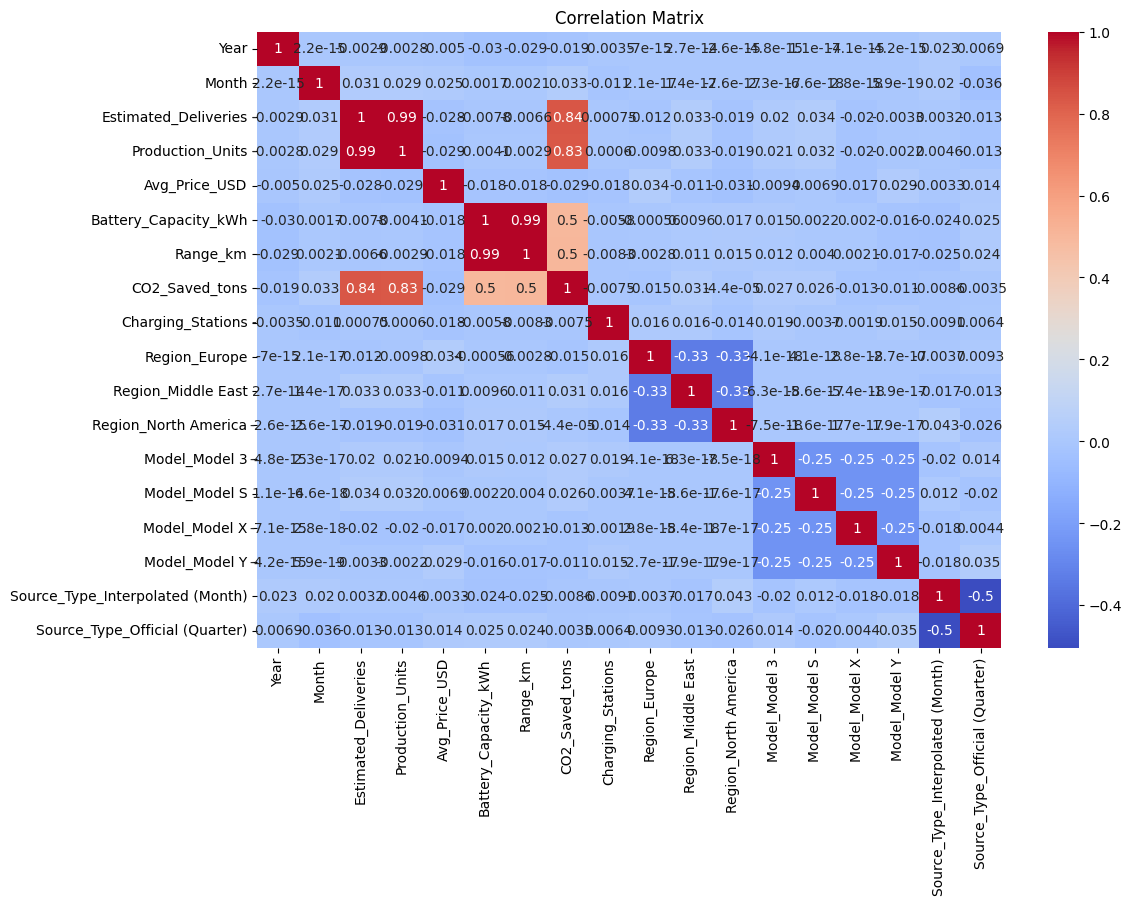

In [14]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

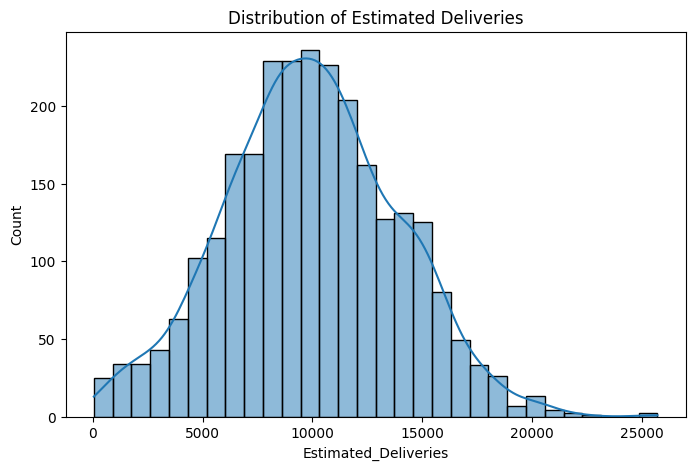

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Estimated_Deliveries"],
    bins=30,
    kde=True
)

plt.title("Distribution of Estimated Deliveries")
plt.show()

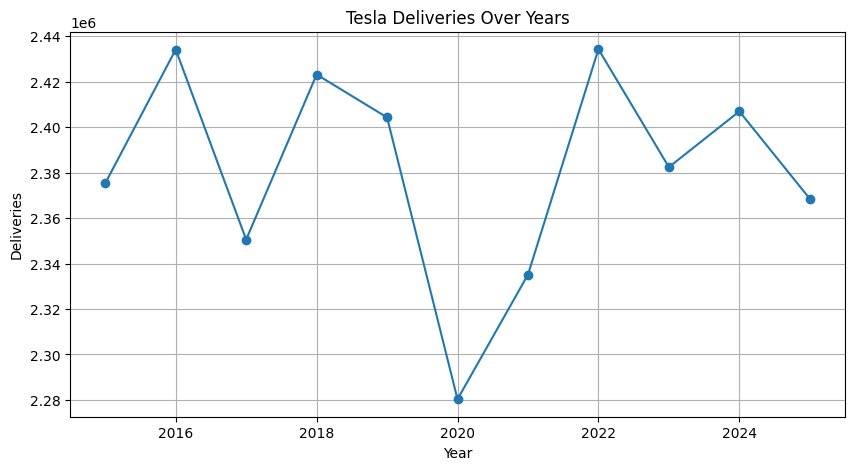

In [16]:
yearly_sales = df.groupby(
    "Year"
)["Estimated_Deliveries"].sum()

plt.figure(figsize=(10,5))

yearly_sales.plot(
    marker="o"
)

plt.title("Tesla Deliveries Over Years")
plt.ylabel("Deliveries")
plt.grid(True)

plt.show()

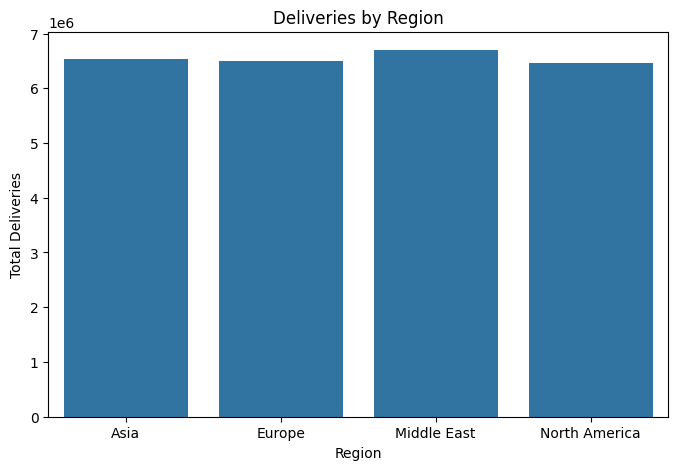

In [17]:
region_sales = dt.groupby(
    "Region"
)["Estimated_Deliveries"].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Deliveries by Region")
plt.ylabel("Total Deliveries")
plt.show()

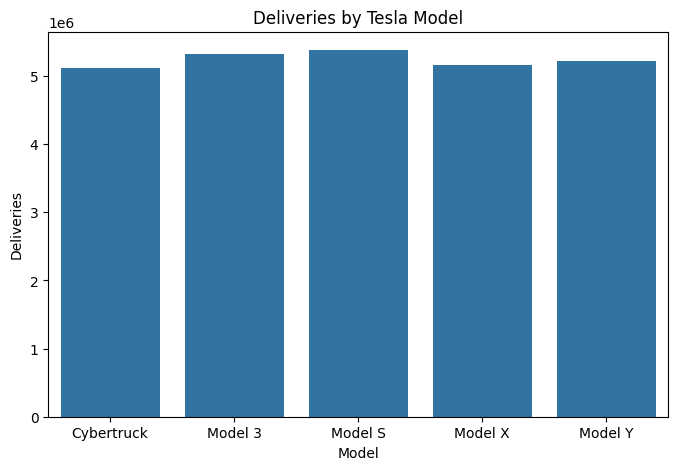

In [18]:
model_sales = dt.groupby(
    "Model"
)["Estimated_Deliveries"].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=model_sales.index,
    y=model_sales.values
)

plt.title("Deliveries by Tesla Model")
plt.ylabel("Deliveries")
plt.show()

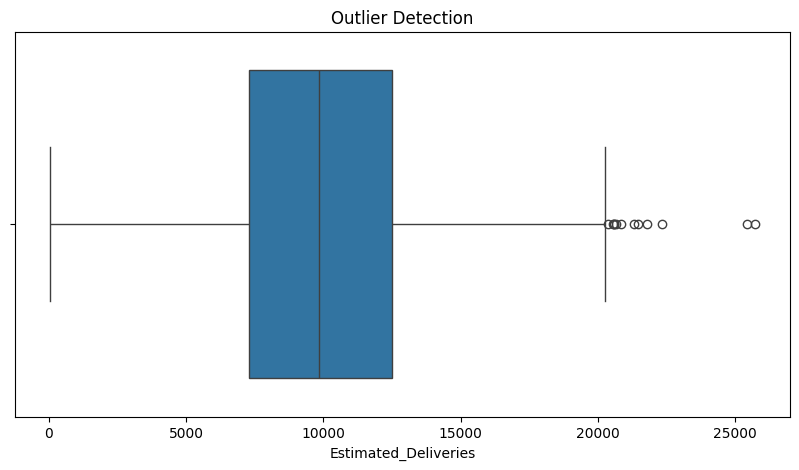

In [19]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["Estimated_Deliveries"]
)

plt.title("Outlier Detection")
plt.show()

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [21]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        random_state=42
    )
}

In [22]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )



In [23]:
print(f"\n{name}")
print("-" * 30)
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


Random Forest
------------------------------
MAE : 320.9519128787879
RMSE: 404.9619442555869
R2 Score: 0.9889983223977038


Hyperparameter tuning


In [24]:
from sklearn.model_selection import GridSearchCV

In [25]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}


In [26]:
rf = RandomForestRegressor(
    random_state=42
)

In [27]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [28]:
best_rf = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [29]:
y_pred = best_rf.predict(X_test)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)



In [30]:
print("\nTuned Random Forest")
print("-" * 30)
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


Tuned Random Forest
------------------------------
MAE : 319.8945749270984
RMSE: 404.15262295799334
R2 Score: 0.9890422524254586


Important feature detection

In [31]:
importance = best_rf.feature_importances_

feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

print(feature_importance_df.head(10))

                             Feature  Importance
2                   Production_Units    0.990748
6                     CO2_Saved_tons    0.002360
5                           Range_km    0.001431
3                      Avg_Price_USD    0.001284
7                  Charging_Stations    0.001139
0                               Year    0.000850
1                              Month    0.000767
15  Source_Type_Interpolated (Month)    0.000155
14                     Model_Model Y    0.000155
10              Region_North America    0.000155


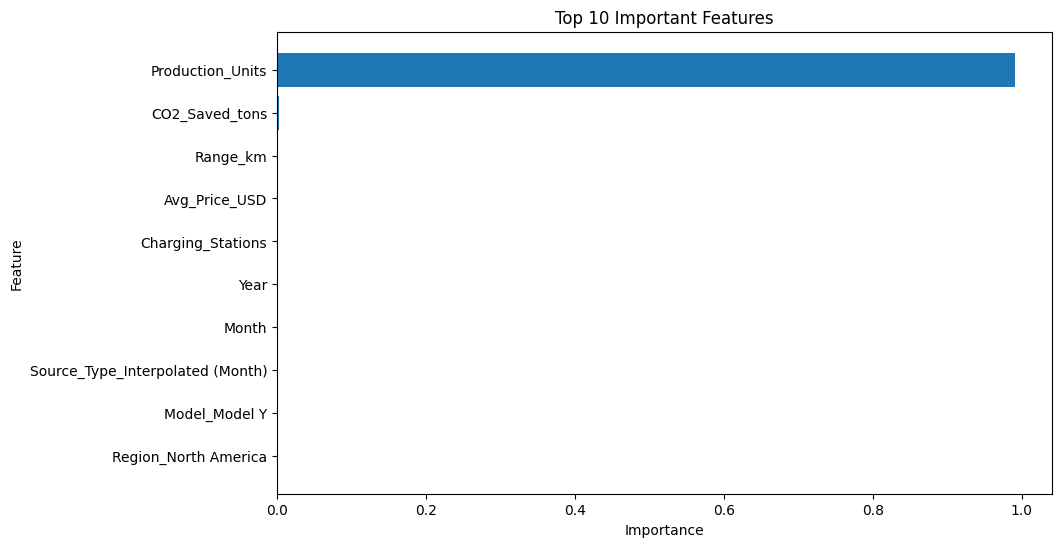

In [32]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df["Feature"][:10],
    feature_importance_df["Importance"][:10]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 10 Important Features"
)

plt.gca().invert_yaxis()

plt.show()

Time-Series forecasting

In [33]:
dt["Date"] = pd.to_datetime(
    dt["Year"].astype(str)
    + "-"
    + dt["Month"].astype(str)
)

In [34]:
monthly_sales = (
    dt.groupby("Date")
    ["Estimated_Deliveries"]
    .sum()
)

print(monthly_sales.head())

Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Name: Estimated_Deliveries, dtype: int64


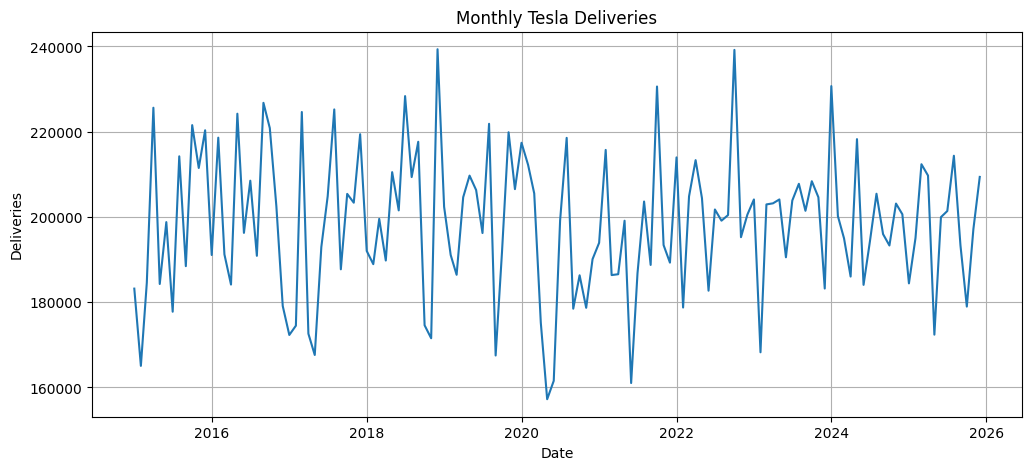

In [35]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales
)

plt.title(
    "Monthly Tesla Deliveries"
)

plt.xlabel("Date")
plt.ylabel("Deliveries")

plt.grid(True)

plt.show()

In [36]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(
    monthly_sales,
    order=(5,1,0)
)

model_fit = model.fit()
forecast = model_fit.forecast(
    steps=12
)

print(forecast)

2026-01-01    203819.655291
2026-02-01    202894.176208
2026-03-01    199011.662577
2026-04-01    198667.010489
2026-05-01    200971.493839
2026-06-01    201391.449843
2026-07-01    201412.663910
2026-08-01    201031.409119
2026-09-01    200601.086701
2026-10-01    200710.068214
2026-11-01    200864.721560
2026-12-01    200936.680134
Freq: MS, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Forecast Visualization

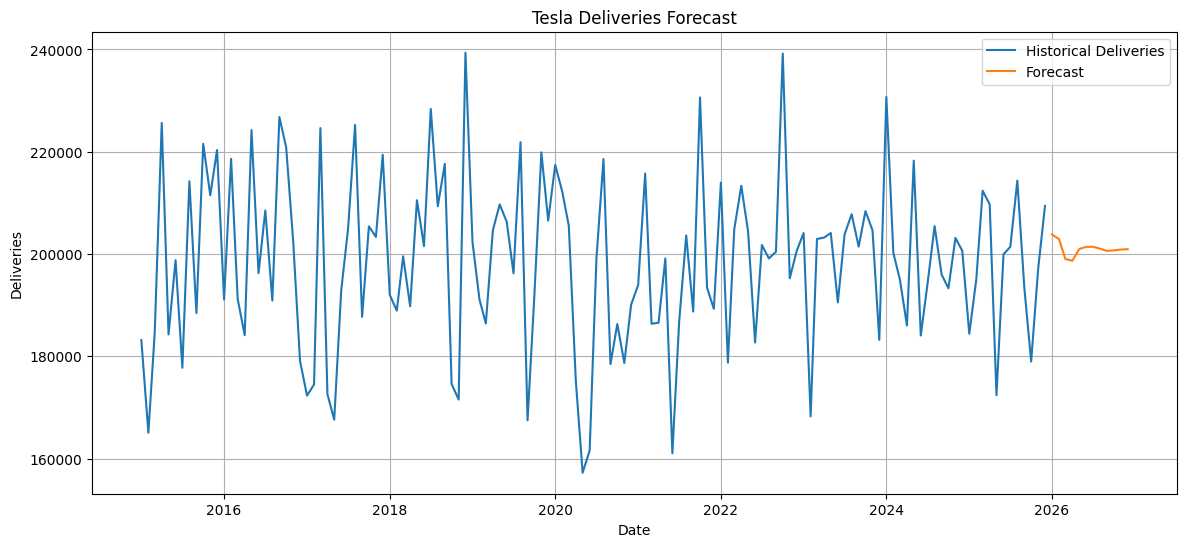

In [37]:
plt.figure(figsize=(14,6))


plt.plot(
    monthly_sales,
    label="Historical Deliveries"
)
plt.plot(
    forecast.index,
    forecast.values,
    label="Forecast",
)

plt.title(
    "Tesla Deliveries Forecast"
)

plt.xlabel("Date")
plt.ylabel("Deliveries")

plt.legend()
plt.grid(True)

plt.show()